# **災害データチャレンジ Part 2: 関数を使ってデータストーリーテリングを強化しよう**

災害データチャレンジの第2部では、**データストーリーテリング能力を高めるための関数作成**に取り組みます。  
関数を効果的に使うことで、プレゼンテーションに必要な**情報豊かなビジュアル**をより簡単に作成する方法を学びましょう。


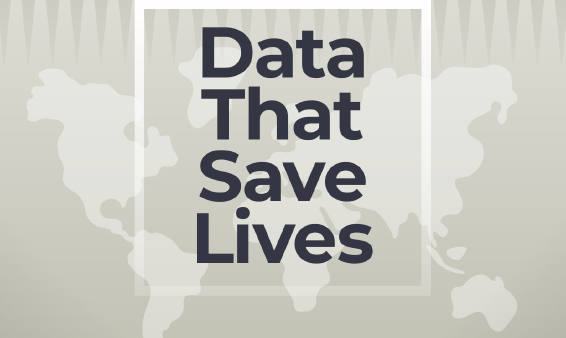

### **ゴール**
このチャレンジの終わりには、関数を活用して次のようなデータストーリーテリングの技術を身に付けることができます:
- 複数のデータ条件に基づいたグラフの生成。
- 簡単に再利用可能なコードの構築。
- プレゼンテーションで効果的に使えるビジュアル作成。

https://www.emdat.be/


## まずはデータの読み込みから

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# PDの日本語フォントをサポート
# plt.rcParams['font.family'] = 'Gothic'

# Macの日本語フォントをサポート
plt.rcParams['font.family'] = 'Hiragino Sans'

# CSVファイルからデータセットを読み込む
csv_file_path = 'emdat.csv'  # CSVファイルのパスに置き換えてください
emdat = pd.read_csv(csv_file_path)

# データセットの最初の数行を表示
emdat.head()

ModuleNotFoundError: No module named 'plotly'

## 関数！So useful!

Functions, 関数は "reusable code" 要するに、**再利用可能なコードブロック**。

つまり、関数は「何かをインプット」したら、「何かをアウトプット」してくれる。

例えば：

In [ ]:
def reitaku_is(feeling):
    """
    指定された感情を使って麗澤大学についてのメッセージを表示します。

    Args:
        feeling (str): 麗澤大学に対する感情や印象を表す文字列。

    Example:
        reitaku_is("素晴らしい")
        # 出力: 麗澤大学は素晴らしいです。
    """
    print("麗澤大学は" + feeling + "です。")

In [ ]:
reitaku_is("最高")

麗澤大学は最高です。


Well, あまり useful ではないよね〜

では、これは？

In [ ]:
# リスト内の数値の平均を出力する関数
def average(numbers):
    total = 0
    for number in numbers:
        total += number
    return total / len(numbers)

In [ ]:
average([1, 2, 3, 4, 5, 6])

3.5

いいね〜。もっと見たい？では、visual output はどう？

In [ ]:
# 円グラフを作成する関数
def pie_chart(labels, sizes):
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.axis('equal')
    plt.show()

C:\Users\aom20\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aom20\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aom20\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aom20\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aom20\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py

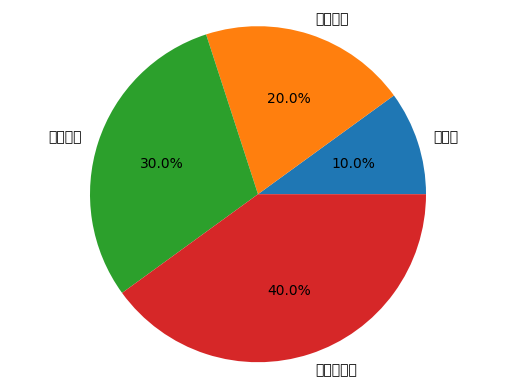

In [ ]:
pie_chart(['工学部', '国際学部', '経済学部', '外国語学部'], [10, 20, 30, 40])

In [ ]:
# 棒グラフを作成する関数
def bar_chart(labels, values):
    plt.bar(labels, values)
    plt.show()

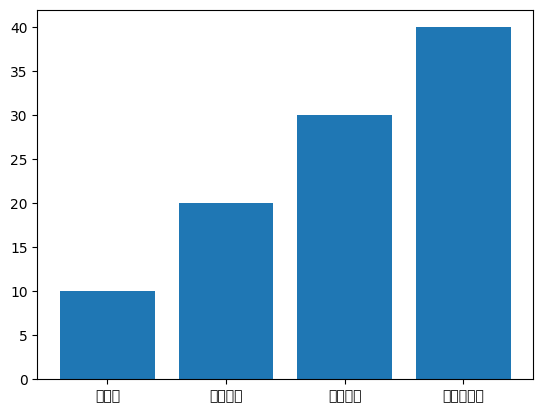

In [ ]:
bar_chart(['工学部', '国際学部', '経済学部', '外国語学部'], [10, 20, 30, 40])

In [ ]:
# 散布図を作成する関数
def scatter_plot(x, y):
    plt.scatter(x, y)
    plt.show()

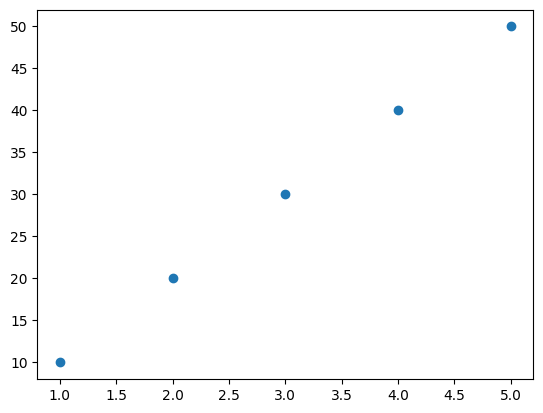

In [ ]:
scatter_plot([1, 2, 3, 4, 5], [10, 20, 30, 40, 50])

In [ ]:
# 線グラフを作成する関数
def line_chart(x, y):
    plt.plot(x, y)
    plt.show()

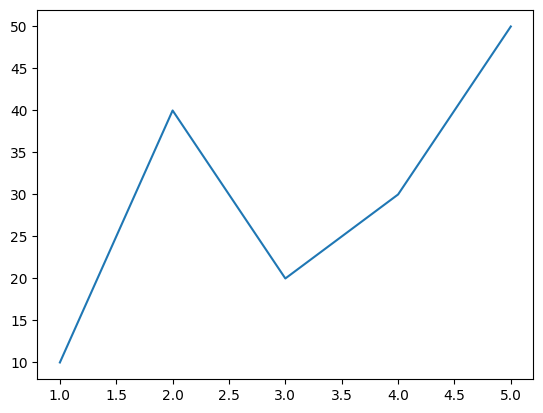

In [ ]:
line_chart([1, 2, 3, 4, 5], [10, 40, 20, 30, 50])

なるほど、でももっとカッコいいものないの？

では、マップや３Dチャートはどう？

In [ ]:
# 地図を作成する関数
import folium

def map(latitude, longitude):
    m = folium.Map(location=[latitude, longitude])
    # marker
    folium.Marker([latitude, longitude], popup='Here').add_to(m)
    return m

In [ ]:
map(35.681236, 139.767125)

In [ ]:
# try other places

In [ ]:
# 3D散布図を作成する関数
def scatter_3d(x, y, z):
    fig = px.scatter_3d(x=x, y=y, z=z)
    fig.show()
    

In [ ]:
scatter_3d([1, 2, 3, 4, 5], [10, 20, 30, 40, 50], [100, 200, 300, 400, 1500])

NameError: name 'px' is not defined

じゃ〜データから関数は作ったらどうなる？

では、

In [ ]:
def get_disaster_summary(iso_code):
    # 指定されたISOコードのデータセットをフィルタリング
    country_data = emdat[emdat['ISO'] == iso_code]
    
    # 国名を抽出
    country_name = country_data['Country'].iloc[0]
    
    # 災害の総数を計算
    total_disasters = country_data.shape[0]
    
    # 死者数の総数を計算
    total_deaths = country_data['Total Deaths'].sum()
    
    # 結果を表示
    print('国:', country_name)
    print('災害の総数:', total_disasters)
    print('死者数の総数:', total_deaths)

In [ ]:
# 使用例
get_disaster_summary('JPN')

get_disaster_summary('USA')

get_disaster_summary('IND')

get_disaster_summary('CHN')

get_disaster_summary('PHL')


NameError: name 'emdat' is not defined

In [ ]:
# use a loop!
countries = ["JPN","USA","IND","CHN","PHL"]

for country in countries:
    get_disaster_summary(country)

NameError: name 'emdat' is not defined

In [ ]:
# 年ごとの災害数を棒グラフで表示する関数
def disasters_by_year(iso_code):
    # 指定されたISOコードのデータセットをフィルタリング
    country_data = emdat[emdat['ISO'] == iso_code]
    
    # データを年ごとにグループ化し、災害の数をカウント
    disasters_by_year = country_data.groupby('Start Year').size()
    
    # 棒グラフを作成
    bar_chart(disasters_by_year.index, disasters_by_year.values)

In [ ]:
disasters_by_year('JPN')
disasters_by_year('USA')

NameError: name 'emdat' is not defined

In [ ]:
# loop it!
for country in countries:
    disasters_by_year(country)

NameError: name 'emdat' is not defined

すごい！もっともっと！

では、まずは次のコードブロックを実行して、じっくり内容を確認しよう。

In [ ]:
# 1. アメリカ合衆国の災害データをフィルタリング
disasters = emdat[emdat['ISO'] == 'USA']
country_name = disasters['Country'].iloc[0]
min_year = disasters['Start Year'].min()
max_year = disasters['Start Year'].max()

# 2. 各災害タイプの発生回数をカウント
disaster_counts = disasters['Disaster Type'].value_counts().sort_values()

# 3. 横棒グラフを作成
plt.figure(figsize=(10, 6))
bars = plt.barh(disaster_counts.index, disaster_counts.values, color='gray')

# 4. 各棒に数値ラベルを追加
for bar in bars:
    plt.text(
        bar.get_width() + 5,                        # X座標: 棒の端から少し離れた位置
        bar.get_y() + bar.get_height() / 2,         # Y座標: 棒の中央
        bar.get_width(),                            # ラベルテキスト
        va='center',                                # 垂直方向の位置: 中央
        fontsize=8                                  # ラベルのフォントサイズ
    )

# 5. プロットの美観をカスタマイズ
plt.title(f'{country_name}の災害 ({min_year}-{max_year})', fontsize=16, pad=20)
plt.xlabel('頻度', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()  # ラベルのクリッピングを防ぐためにレイアウトを調整

# 6. プロットを表示
plt.show()

では、このチャートを作る関数を作ろう！

## Examples

### **チャレンジ 1: 国ごとの死亡者数を可視化**
- **内容**: 指定した国の災害データを使用し、災害タイプごとの死亡者数を棒グラフで可視化する関数を作成してください。

### **チャレンジ 2: 2つの国の死亡者数を比較**
- **内容**: 指定した2つの国の死亡者数を災害タイプごとに比較する関数を作成してください。

### **チャレンジ 3: 最も致命的な災害トップNを可視化**
- **内容**: 死亡者数が多い順に、最も致命的な災害を上位N件（例: トップ5）可視化する関数を作成してください。

### **チャレンジ 4: 特定の年範囲での死亡者数を可視化**
- **内容**: 特定の年範囲（例: 2000年から2010年）の死亡者数を可視化する関数を作成してください。

### **チャレンジ 5: カスタム可視化を作成**
- **内容**: 学生自身でユニークな関数を作成し、以下のような条件でデータを可視化してください。
  - 複数のパラメータ（例えば、国と災害タイプ）を組み合わせた可視化。
  - 特定の条件を満たすデータ（例: 死亡者数が1,000以上）を強調表示する。



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_disasters(country_name):
    """
    Visualizes total deaths by disaster type for a specified country using bar graph.
    
    Parameters:
    country_name (str): The name of the country (must match exactly as in the CSV, e.g., 'China', 'United States of America')
    """
    # Load the data from emdat.csv
    df = pd.read_csv('emdat.csv')
    
    # Filter by country
    country_df = df[df['Country'] == country_name].copy()  # Use copy to avoid SettingWithCopyWarning
    
    # Handle missing Total Deaths: replace empty strings with 0
    country_df['Total Deaths'] = pd.to_numeric(country_df['Total Deaths'], errors='coerce').fillna(0)
    
    # Group by Disaster Type and sum Total Deaths
    grouped = country_df.groupby('Disaster Type')['Total Deaths'].sum().reset_index()
    
    # Sort by deaths descending for better visualization
    grouped = grouped.sort_values('Total Deaths', ascending=False)
    
    # Plot the bar graph
    plt.figure(figsize=(12, 6))
    plt.bar(grouped['Disaster Type'], grouped['Total Deaths'])
    plt.xlabel('Disaster Type')
    plt.ylabel('Total Deaths')
    plt.title(f'Total Deaths by Disaster Type in {country_name}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

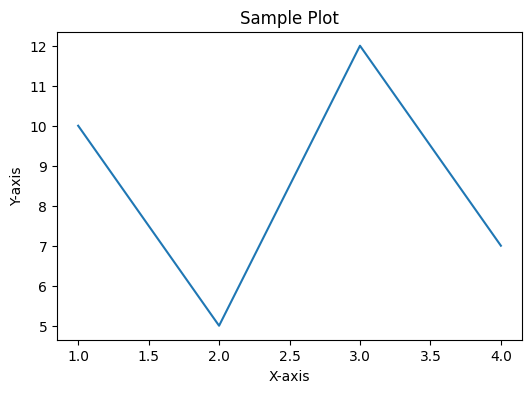

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))      
plt.plot([1, 2, 3, 4], [10, 5, 12, 7])   
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Sample Plot")
plt.show() 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_disasters(country1, country2, csv_path="emdat.csv"):
    """
    Compare total deaths by disaster type between two countries.

    Parameters:
        country1 (str): Name of the first country
        country2 (str): Name of the second country
        csv_path (str): Path to the EMDAT CSV file
    """

    # データ読み込み
    df = pd.read_csv(csv_path)

    # 必要な列のみ抽出（ない場合は列名を調整）
    required_cols = ["Country", "Disaster Type", "Total Deaths"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"CSVに必要な列 '{col}' がありません。")

    # 2カ国のデータ抽出
    df_filtered = df[df["Country"].isin([country1, country2])]

    # 災害タイプごとの死亡者数集計
    grouped = df_filtered.groupby(["Country", "Disaster Type"])["Total Deaths"].sum().unstack(fill_value=0)

    # プロット
    grouped.T.plot(kind="bar", figsize=(12, 6))
    plt.title(f"Deaths by Disaster Type: {country1} vs {country2}")
    plt.xlabel("Disaster Type")
    plt.ylabel("Total Deaths")
    plt.xticks(rotation=45)
    plt.legend(title="Country")
    plt.tight_layout()
    plt.show()

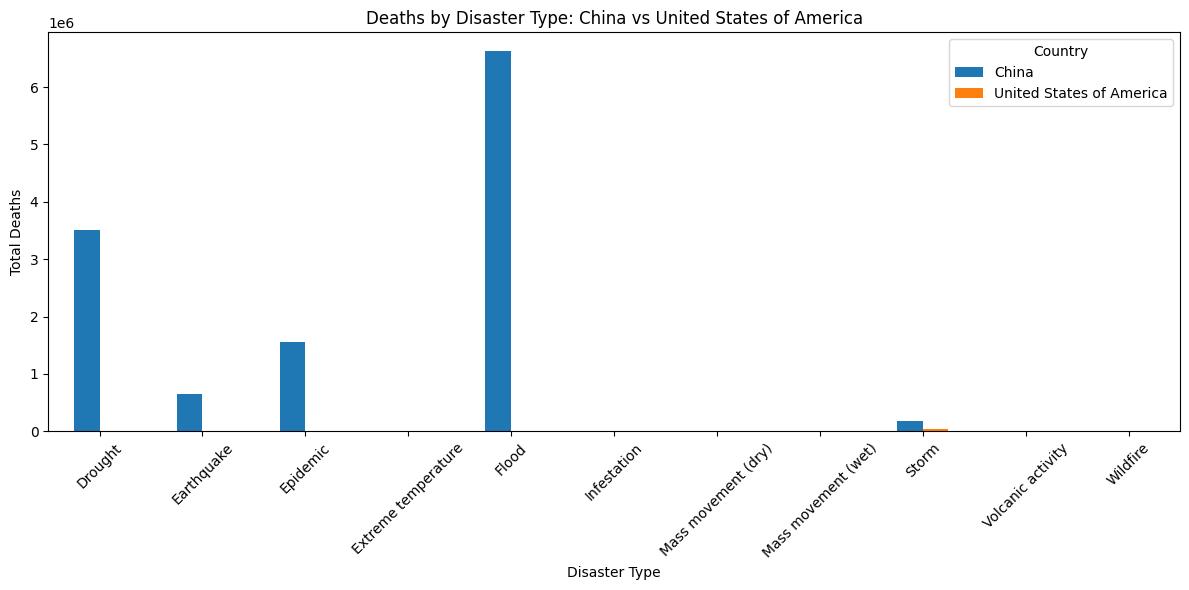

In [8]:
compare_disasters("China", "United States of America")

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_top_deadliest_disasters(N=5, csv_path="emdat.csv"):
    """
    Visualize the top N deadliest disaster types globally.
    
    Parameters:
        N (int): Number of top disaster types to show.
        csv_path (str): Path to the EMDAT CSV file.
    """

    # データ読み込み
    df = pd.read_csv(csv_path)

    # 必要な列のチェック
    required_cols = ["Disaster Type", "Total Deaths"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"CSVに必要な列 '{col}' がありません。")

    # 災害タイプごとの死亡者数を集計
    disaster_deaths = df.groupby("Disaster Type")["Total Deaths"].sum()

    # 死亡者数が多い順に上位N件を取得
    top_disasters = disaster_deaths.sort_values(ascending=False).head(N)

    # プロット
    plt.figure(figsize=(10, 6))
    top_disasters.plot(kind="bar")
    plt.title(f"Top {N} Deadliest Disaster Types")
    plt.xlabel("Disaster Type")
    plt.ylabel("Total Deaths")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

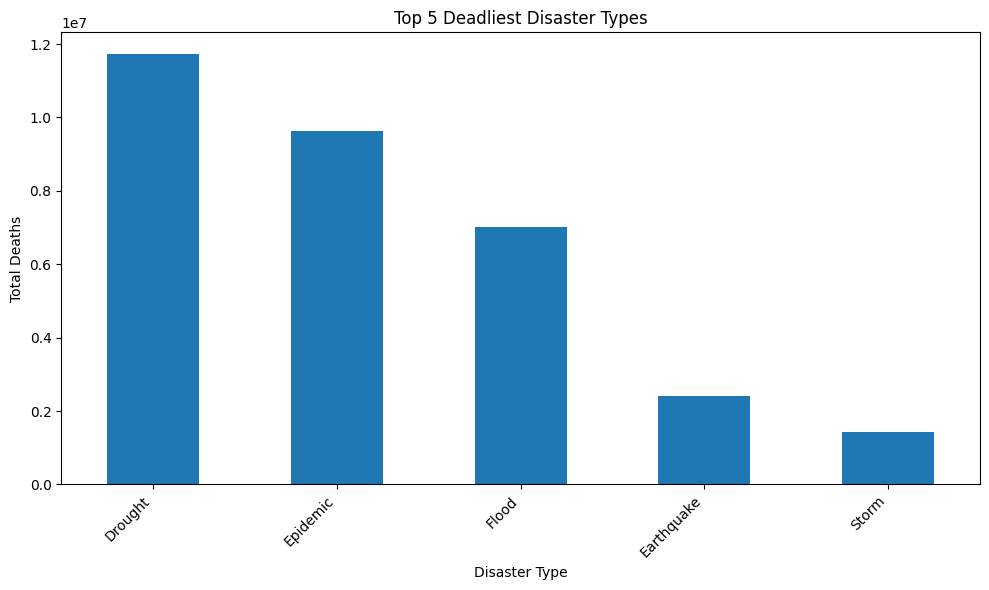

In [10]:
visualize_top_deadliest_disasters(5)

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

def visualize_deaths_2000_2010(csv_path):
    """
    Visualizes total deaths by disaster type between 2000 and 2010.

    Parameters:
        csv_path (str): Path to the CSV file (e.g., 'emdat.csv')
    """

    # CSV 読み込み
    df = pd.read_csv(csv_path)

    # 必要列が存在するかチェック
    required_cols = ['Year', 'Disaster Type', 'Total Deaths']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"CSVに '{col}' 列がありません。")

    # 年でフィルタ（2000〜2010）
    df_filtered = df[(df["Year"] >= 2000) & (df["Year"] <= 2010)]

    # 災害タイプ別に死亡者数を合計
    grouped = df_filtered.groupby("Disaster Type")["Total Deaths"].sum().sort_values(ascending=False)

    # グラフ作成
    plt.figure(figsize=(12, 6))
    plt.bar(grouped.index, grouped.values)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Disaster Type")
    plt.ylabel("Total Deaths")
    plt.title("Total Deaths by Disaster Type (2000–2010)")
    plt.tight_layout()
    plt.show()

In [1]:
visualize_deaths_2000_2010("emdat.csv")

NameError: name 'visualize_deaths_2000_2010' is not defined

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

def highlight_disaster_data(country_list, disaster_types, start_year, end_year, threshold=1000):
    """
    Visualizes deaths for selected countries and disaster types within a year range.
    Bars above a threshold (default: 1000 deaths) are highlighted.

    Parameters:
        country_list (list): List of country names (e.g., ["Japan", "China"])
        disaster_types (list): List of disaster types (e.g., ["Flood", "Earthquake"])
        start_year (int): Start year
        end_year (int): End year
        threshold (int): Death threshold for highlighting (default=1000)
    """

    # データ読み込み
    df = pd.read_csv("emdat.csv")

    # 必要列チェック
    required = {"Country", "Disaster Type", "Year", "Total Deaths"}
    if not required.issubset(df.columns):
        raise ValueError("CSV に必要列 (Country, Disaster Type, Year, Total Deaths) が不足しています。")

    # フィルタリング
    df_filtered = df[
        (df["Country"].isin(country_list)) &
        (df["Disaster Type"].isin(disaster_types)) &
        (df["Year"] >= start_year) &
        (df["Year"] <= end_year)
    ]

    # 国 × 災害タイプで死亡者数集計
    summary = df_filtered.groupby(["Country", "Disaster Type"])["Total Deaths"].sum()

    # プロット準備
    plt.figure(figsize=(12, 7))

    # 棒の色を分ける（threshold 以上 → 赤、それ以外 → 青）
    colors = ["red" if val >= threshold else "steelblue" for val in summary.values]

    # 棒グラフ描画
    summary.plot(kind="bar", color=colors)

    plt.title(f"Deaths by Country & Disaster Type ({start_year}–{end_year})")
    plt.ylabel("Total Deaths")
    plt.xlabel("Country / Disaster Type")
    plt.xticks(rotation=45, ha='right')

    # ハイライト説明
    plt.figtext(
        0.99, 0.01,
        f"* Red bars = deaths ≥ {threshold}",
        ha="right", fontsize=10, color="red"
    )

    plt.tight_layout()
    plt.show()

In [2]:
highlight_disaster_data(
    country_list=["Japan", "China"],
    disaster_types=["Flood", "Earthquake"],
    start_year=2000,
    end_year=2010,
    threshold=1000
)

NameError: name 'highlight_disaster_data' is not defined

In [3]:
highlight_disaster_data(
    country_list=["India", "United States of America"],
    disaster_types=["Storm", "Flood"],
    start_year=1990,
    end_year=2020,
    threshold=5000
)

NameError: name 'highlight_disaster_data' is not defined